In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix,mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA


In [15]:
Data=pd.read_csv("D:/datasets/TSLA/TSLA.csv")
Data=Data[['Open','High','Low','Close']][2499:]
train,test=train_test_split(Data,test_size=0.2,random_state=42)
train,valid=train_test_split(train,test_size=0.2,random_state=42)

scaler=MinMaxScaler()
scaled_train=scaler.fit_transform(train)
train=pd.DataFrame({'Open':scaled_train[:,0],'High':scaled_train[:,1],'Low':scaled_train[:,2],'Close':scaled_train[:,3]})
scaled_val=scaler.fit_transform(valid)
valid=pd.DataFrame({'Open':scaled_val[:,0],'High':scaled_val[:,1],'Low':scaled_val[:,2],'Close':scaled_val[:,3]})
scaled_test=scaler.fit_transform(test)
test=pd.DataFrame({'Open':scaled_test[:,0],'High':scaled_test[:,1],'Low':scaled_test[:,2],'Close':scaled_test[:,3]})

train,train_ans=train[['Open','High','Low']],train['Close']
valid,valid_ans=valid[['Open','High','Low']],valid['Close']
test,test_ans=test[['Open','High','Low']],test['Close']


In [16]:
valid

,Open,High,Low
0,0.496258,0.494467,0.510555
1,0.409455,0.415477,0.434161
2,0.460098,0.476643,0.506731
3,0.518162,0.513686,0.546719
4,0.881504,0.894283,0.927319
...,...,...,...
119,0.701516,0.692188,0.751553
120,0.491534,0.499310,0.523962
121,0.417700,0.414032,0.429607
122,0.004107,0.004253,0.017114


In [17]:
print(valid.describe(),'\n\n')
valid.info()

             Open        High         Low
count  124.000000  124.000000  124.000000
mean     0.515073    0.523659    0.550181
std      0.226847    0.228589    0.237264
min      0.000000    0.000000    0.000000
25%      0.369157    0.377302    0.395889
50%      0.519501    0.528642    0.558307
75%      0.665325    0.681302    0.714165
max      1.000000    1.000000    1.000000 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    124 non-null    float64
 1   High    124 non-null    float64
 2   Low     124 non-null    float64
dtypes: float64(3)
memory usage: 3.0 KB


In [18]:
print(train.describe(),'\n\n')
train.info()

             Open        High         Low
count  493.000000  493.000000  493.000000
mean     0.469404    0.475467    0.462588
std      0.204677    0.208070    0.202840
min      0.000000    0.000000    0.000000
25%      0.344779    0.351228    0.346195
50%      0.467429    0.473890    0.459866
75%      0.619883    0.625523    0.604599
max      1.000000    1.000000    1.000000 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    493 non-null    float64
 1   High    493 non-null    float64
 2   Low     493 non-null    float64
dtypes: float64(3)
memory usage: 11.7 KB


<AxesSubplot:>

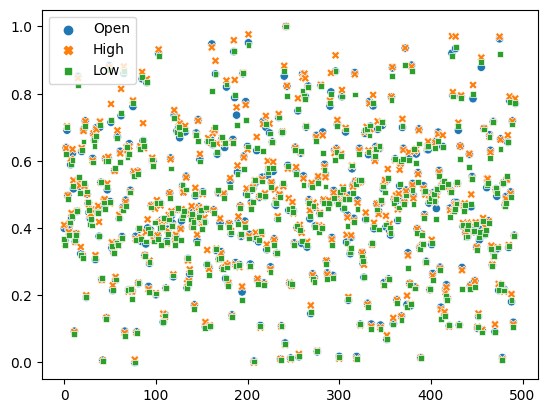

In [19]:
sns.scatterplot(train)

In [20]:
model=keras.models.Sequential([
    keras.layers.Dense(100,kernel_initializer='he_normal',activation='elu',input_shape=(3,)),
    keras.layers.Dense(50,kernel_initializer='he_normal',activation='elu'),
    keras.layers.Dense(10,kernel_initializer='he_normal',activation='elu'),
    keras.layers.Dense(1,kernel_initializer='he_normal'),
])
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_8 (Dense)              (None, 100)               400       
_________________________________________________________________
dense_9 (Dense)              (None, 50)                5050      
_________________________________________________________________
dense_10 (Dense)             (None, 10)                510       
_________________________________________________________________
dense_11 (Dense)             (None, 1)                 11        
Total params: 5,971
Trainable params: 5,971
Non-trainable params: 0
_________________________________________________________________


In [21]:
model.compile(loss=keras.losses.Huber(),optimizer=keras.optimizers.Nadam(learning_rate=0.0001),metrics=['mse'])

In [22]:
history=model.fit(train,train_ans,validation_data=(valid,valid_ans),epochs=200)

Train on 493 samples, validate on 124 samples
Epoch 1/200
493/493 [==============================] - 0s 360us/sample - loss: 0.1336 - mean_squared_error: 0.2672 - val_loss: 0.0625 - val_mean_squared_error: 0.1250
Epoch 2/200
493/493 [==============================] - 0s 89us/sample - loss: 0.0162 - mean_squared_error: 0.0325 - val_loss: 0.0054 - val_mean_squared_error: 0.0108
Epoch 3/200
493/493 [==============================] - 0s 86us/sample - loss: 6.7397e-04 - mean_squared_error: 0.0013 - val_loss: 0.0012 - val_mean_squared_error: 0.0023
Epoch 4/200
493/493 [==============================] - 0s 83us/sample - loss: 5.1552e-04 - mean_squared_error: 0.0010 - val_loss: 0.0015 - val_mean_squared_error: 0.0029
Epoch 5/200
493/493 [==============================] - 0s 81us/sample - loss: 4.2575e-04 - mean_squared_error: 8.5151e-04 - val_loss: 0.0017 - val_mean_squared_error: 0.0034
Epoch 6/200
493/493 [==============================] - 0s 87us/sample - loss: 4.0956e-04 - mean_squared_err

<AxesSubplot:>

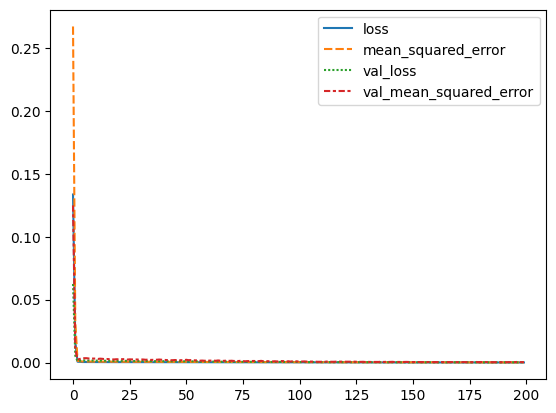

In [23]:
sns.lineplot(data=pd.DataFrame(history.history))

In [29]:
prediction=model.predict(test)
rmse=np.sqrt(mean_squared_error(test_ans,prediction))
print(rmse)

0.013106794794675402
